# RNA-only moscot end-to-end notebook


In [ ]:
# Environment install cell
# Run this once, then restart the runtime before continuing.

!pip -q uninstall -y moscot ott-jax jax jaxlib jax-cuda12-plugin jax-cuda12-pjrt

!pip install -q \
  "pandas==2.2.2" \
  scanpy anndata numpy scipy scikit-learn matplotlib seaborn

!pip install -q \
  "jax[cpu]==0.7.2" \
  "jaxlib==0.7.2" \
  "ott-jax==0.6.0" \
  "moscot==0.5.0"

In [2]:
import os
os.environ["JAX_PLATFORMS"] = "cpu"

import importlib.metadata as md

for pkg in [
    "moscot",
    "ott-jax",
    "jax",
    "jaxlib",
    "jax-cuda12-plugin",
    "jax-cuda12-pjrt",
    "ml-dtypes",
    "flax",
    "optax",
    "lineax",
    "equinox",
    "scanpy",
    "anndata",
    "numpy",
    "scipy",
    "pandas",
]:
    try:
        print(f"{pkg:20s}", md.version(pkg))
    except md.PackageNotFoundError:
        print(f"{pkg:20s}", "NOT INSTALLED")

import jax
print("jax devices:", jax.devices())

try:
    from jax.interpreters import batching
    print("has batching.is_vmappable:", hasattr(batching, "is_vmappable"))
except Exception as e:
    print("batching check failed:", repr(e))

from moscot.problems.generic import SinkhornProblem
print("moscot SinkhornProblem import succeeded")

moscot               0.5.0
ott-jax              0.6.0
jax                  0.7.2
jaxlib               0.7.2
jax-cuda12-plugin    NOT INSTALLED
jax-cuda12-pjrt      NOT INSTALLED
ml-dtypes            0.5.4
flax                 0.11.2
optax                0.2.8
lineax               0.1.0
equinox              0.13.8
scanpy               1.12
anndata              0.12.13
numpy                2.0.2
scipy                1.16.3
pandas               2.2.2
jax devices: [CpuDevice(id=0)]
has batching.is_vmappable: True


/tmp/ipykernel_13280/3576309823.py:34: DeprecationWarning: jax.interpreters.batching.is_vmappable is deprecated. It is an internal API.
  print("has batching.is_vmappable:", hasattr(batching, "is_vmappable"))


moscot SinkhornProblem import succeeded


In [3]:
# Colab only. Comment this out if running locally.
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [4]:
# -----------------------------
# User paths / run settings
# -----------------------------
PROJECT_DIR = "/content/drive/MyDrive/High_Dim_Bio_Stats/Project"
RNA_DATA_PATH = f"{PROJECT_DIR}/Copy of 040_epi_rna_filtered.h5ad"

CONTROL_LABEL = "NTC"
CONDITION_COL = "mixscape_class"
ANNOTATION_COL = "annot"  # Set to None if this column is unavailable.
TARGET_LABELS = None       # None auto-detects labels containing "KO".

RUN_ROOT = f"{PROJECT_DIR}/moscot_RNA_only_end_to_end"
HANDOFF_DIR = f"{RUN_ROOT}/handoff"

N_TOP_GENES = 2000
N_RNA_PCS = 50
MIN_CELLS = 10
TARGET_SUM = 1e4
TEST_SIZE = 0.20
RANDOM_SEED = 0

EPSILON_GRID = [1e-3, 3e-3, 1e-2]
TAU_GRID = [(1.0, 1.0), (0.95, 0.95), (0.9, 0.9)]

BATCH_SIZE = 512
RANK = -1
MAX_EVAL_CELLS_PER_GROUP = 2000
MIN_CONTROL_CELLS = 100
MIN_TARGET_CELLS = 50
SKIP_EXISTING = True


In [5]:
import os
import re
import json
from pathlib import Path

import numpy as np
import pandas as pd
import scanpy as sc
import anndata as ad
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import sparse
from scipy.spatial.distance import cdist
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline

from moscot.problems.generic import SinkhornProblem

np.random.seed(RANDOM_SEED)
Path(RUN_ROOT).mkdir(parents=True, exist_ok=True)
Path(HANDOFF_DIR).mkdir(parents=True, exist_ok=True)

print("scanpy:", sc.__version__)
print("RUN_ROOT:", RUN_ROOT)
print("HANDOFF_DIR:", HANDOFF_DIR)

scanpy: 1.12
RUN_ROOT: /content/drive/MyDrive/High_Dim_Bio_Stats/Project/moscot_RNA_only_end_to_end
HANDOFF_DIR: /content/drive/MyDrive/High_Dim_Bio_Stats/Project/moscot_RNA_only_end_to_end/handoff


/tmp/ipykernel_13280/2219864623.py:28: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  print("scanpy:", sc.__version__)


## Helper functions


In [6]:
def slugify_label(label: str) -> str:
    slug = re.sub(r"[^A-Za-z0-9]+", "_", str(label)).strip("_")
    return slug or "target"


def dense_X(a_or_X):
    X = a_or_X.X if hasattr(a_or_X, "X") else a_or_X
    return X.toarray() if sparse.issparse(X) else np.asarray(X)


def add_stable_split(adata, condition_col="condition", split_col="split", test_size=0.2, seed=0):
    """Stratified train/test split within condition."""
    labels = adata.obs[condition_col].astype(str).values
    idx = np.arange(adata.n_obs)
    adata.obs[split_col] = "train"
    sss = StratifiedShuffleSplit(n_splits=1, test_size=test_size, random_state=seed)
    _, test_idx = next(sss.split(idx, labels))
    adata.obs.iloc[test_idx, adata.obs.columns.get_loc(split_col)] = "test"
    return adata


def zscore_embedding(X, eps=1e-8):
    X = np.asarray(X, dtype=np.float32)
    mu = X.mean(axis=0, keepdims=True)
    sd = X.std(axis=0, keepdims=True)
    sd[sd < eps] = 1.0
    return ((X - mu) / sd).astype(np.float32), mu.astype(np.float32), sd.astype(np.float32)


def safe_sample_idx(n, max_n=2000, seed=0):
    if n <= max_n:
        return np.arange(n)
    rng = np.random.default_rng(seed)
    return np.sort(rng.choice(n, size=max_n, replace=False))




def median_rbf_gamma(*arrays, max_n=2000, seed=0):
    """
    Choose one RBF bandwidth for all distributions being compared.

    This is the common-evaluation version used in the final notebook:
    the numerator MMD and denominator MMD in the ratio use the same gamma,
    so they are measured with the same kernel/ruler.
    """
    sampled = []
    for k, X in enumerate(arrays):
        X = np.asarray(X, dtype=np.float32)
        if len(X) == 0:
            continue
        sampled.append(X[safe_sample_idx(len(X), max_n, seed + 17 * k)])
    if len(sampled) == 0:
        return np.nan

    Z = np.vstack(sampled)
    Zs = Z[safe_sample_idx(len(Z), min(1000, len(Z)), seed + 999)]
    D = cdist(Zs, Zs, metric="sqeuclidean")
    positive = D[D > 0]
    if len(positive) == 0:
        return 1.0
    med = np.median(positive)
    return float(1.0 / max(med, 1e-8))


def rbf_mmd2(X, Y, gamma=None, max_n=2000, seed=0):
    """
    Biased RBF MMD^2. Smaller means closer distributions.

    If gamma is provided, this uses that fixed bandwidth. If gamma=None,
    it falls back to the old behavior and chooses a median bandwidth from X and Y.
    """
    X = np.asarray(X, dtype=np.float32)
    Y = np.asarray(Y, dtype=np.float32)
    X = X[safe_sample_idx(len(X), max_n, seed)]
    Y = Y[safe_sample_idx(len(Y), max_n, seed + 1)]

    if gamma is None:
        gamma = median_rbf_gamma(X, Y, max_n=min(1000, max_n), seed=seed + 2)

    Kxx = np.exp(-gamma * cdist(X, X, metric="sqeuclidean")).mean()
    Kyy = np.exp(-gamma * cdist(Y, Y, metric="sqeuclidean")).mean()
    Kxy = np.exp(-gamma * cdist(X, Y, metric="sqeuclidean")).mean()
    return float(Kxx + Kyy - 2 * Kxy)


def common_eval_mmd_metrics(X_ctrl, X_target, X_bary, max_n=2000, seed=0):
    """
    Final/common evaluation metric.

    The same RBF bandwidth is used for the raw control-vs-perturbed baseline
    and the barycentric-vs-perturbed comparison.
    """
    gamma = median_rbf_gamma(X_ctrl, X_target, X_bary, max_n=max_n, seed=seed)
    mmd_ctrl = rbf_mmd2(X_ctrl, X_target, gamma=gamma, max_n=max_n, seed=seed)
    mmd_bary = rbf_mmd2(X_bary, X_target, gamma=gamma, max_n=max_n, seed=seed)
    return {
        "mmd2_gamma_common_eval": float(gamma),
        "mmd2_control_to_perturbed": float(mmd_ctrl),
        "mmd2_bary_to_perturbed": float(mmd_bary),
        "mmd2_ratio_bary_to_pert_over_ctrl_to_pert": float(mmd_bary / max(mmd_ctrl, 1e-12)),
    }


def classifier_two_sample(X, Y, max_n=2000, seed=0):
    """
    Train/test logistic classifier to distinguish X vs Y.
    Good alignment should make this hard: accuracy/AUC near 0.5.
    """
    X = np.asarray(X, dtype=np.float32)
    Y = np.asarray(Y, dtype=np.float32)
    X = X[safe_sample_idx(len(X), max_n, seed)]
    Y = Y[safe_sample_idx(len(Y), max_n, seed + 1)]

    Z = np.vstack([X, Y])
    y = np.r_[np.zeros(len(X)), np.ones(len(Y))]

    if min(np.bincount(y.astype(int))) < 10:
        return {"clf_acc": np.nan, "clf_auc": np.nan}

    sss = StratifiedShuffleSplit(n_splits=1, test_size=0.3, random_state=seed)
    train_idx, test_idx = next(sss.split(Z, y))
    clf = make_pipeline(
        StandardScaler(),
        LogisticRegression(max_iter=2000, class_weight="balanced", random_state=seed),
    )
    clf.fit(Z[train_idx], y[train_idx])
    pred = clf.predict(Z[test_idx])
    score = clf.predict_proba(Z[test_idx])[:, 1]
    return {
        "clf_acc": float(accuracy_score(y[test_idx], pred)),
        "clf_auc": float(roc_auc_score(y[test_idx], score)),
    }


def transport_matrix_to_numpy(tm):
    """Convert moscot/OTT transport matrix to dense numpy."""
    if sparse.issparse(tm):
        return tm.toarray()
    if hasattr(tm, "todense"):
        return np.asarray(tm.todense())
    if hasattr(tm, "toarray"):
        return np.asarray(tm.toarray())
    return np.asarray(tm)


def get_solution(problem, source="control", target="perturbed"):
    """moscot versions differ slightly in solution-key representation."""
    for key in [(source, target), f"{source}_{target}", f"{source}->{target}"]:
        try:
            return problem.solutions[key]
        except Exception:
            pass
    if len(problem.solutions) == 1:
        return list(problem.solutions.values())[0]
    raise KeyError(f"Could not find solution for {source}->{target}. Available: {list(problem.solutions.keys())}")


def compute_barycentric_projection(P, X_target):
    """
    Barycentric target coordinate per source cell:
    B_i = sum_j P_ij y_j / sum_j P_ij
    """
    P = np.asarray(P, dtype=np.float64)
    row_mass = P.sum(axis=1, keepdims=True)
    row_mass[row_mass == 0] = 1.0
    return ((P @ np.asarray(X_target, dtype=np.float64)) / row_mass).astype(np.float32)


def coupling_diagnostics(P):
    P = np.asarray(P, dtype=np.float64)
    row_mass = P.sum(axis=1)
    col_mass = P.sum(axis=0)
    Pn_rows = P / np.maximum(row_mass[:, None], 1e-30)
    row_entropy = -(Pn_rows * np.log(np.maximum(Pn_rows, 1e-30))).sum(axis=1)
    eff_targets = np.exp(row_entropy)
    return {
        "transport_mass_total": float(P.sum()),
        "row_mass_min": float(row_mass.min()),
        "row_mass_max": float(row_mass.max()),
        "col_mass_min": float(col_mass.min()),
        "col_mass_max": float(col_mass.max()),
        "row_entropy_mean": float(row_entropy.mean()),
        "row_entropy_median": float(np.median(row_entropy)),
        "effective_targets_per_source_mean": float(eff_targets.mean()),
        "effective_targets_per_source_median": float(np.median(eff_targets)),
    }


def label_transfer_metrics(P, source_obs, target_obs, annotation_col):
    if annotation_col is None or annotation_col not in source_obs.columns or annotation_col not in target_obs.columns:
        return {}

    src_labels = source_obs[annotation_col].astype(str).values
    tgt_labels = target_obs[annotation_col].astype(str).values
    classes = np.array(sorted(set(src_labels).union(set(tgt_labels))))
    class_to_idx = {c: i for i, c in enumerate(classes)}

    Y_tgt = np.zeros((len(tgt_labels), len(classes)), dtype=np.float64)
    for i, lab in enumerate(tgt_labels):
        Y_tgt[i, class_to_idx[lab]] = 1.0

    P = np.asarray(P, dtype=np.float64)
    row_mass = P.sum(axis=1, keepdims=True)
    row_mass[row_mass == 0] = 1.0
    probs = (P @ Y_tgt) / row_mass
    pred = classes[probs.argmax(axis=1)]

    acc = np.mean(pred == src_labels)
    maxprob = probs.max(axis=1).mean()
    return {
        f"{annotation_col}_label_transfer_acc_source_to_target": float(acc),
        f"{annotation_col}_label_transfer_mean_max_prob": float(maxprob),
    }



def load_transport_npz(transport_path):
    """Load a saved transport plan while preserving object/string metadata."""
    z = np.load(transport_path, allow_pickle=True)
    return z


def recompute_common_eval_metrics_from_files(info, eval_attr=None):
    """
    Recompute final/common RNA-PCA evaluation metrics from saved files.

    This lets us update old metrics/summary CSVs without changing the core
    handoff files. It uses the saved transport plan P and the saved moscot
    input cells, then computes the explicit plan barycenter P @ target_RNA_PCA.
    """
    input_path = Path(info["input_path"])
    transport_path = Path(info["transport_path"])

    adata_in = sc.read_h5ad(input_path)
    z = load_transport_npz(transport_path)
    P = np.asarray(z["P"], dtype=np.float32)

    if "source_obs_names" in z.files and "target_obs_names" in z.files:
        source_names = [str(x) for x in z["source_obs_names"]]
        target_names = [str(x) for x in z["target_obs_names"]]
        source = adata_in[source_names].copy()
        target = adata_in[target_names].copy()
    else:
        source = adata_in[adata_in.obs["condition"].astype(str).eq("control")].copy()
        target = adata_in[adata_in.obs["condition"].astype(str).eq("perturbed")].copy()

    # For this RNA-only notebook, adata_in.X is already the RNA PCA space used by moscot.
    # Keep eval_attr as an optional escape hatch if a future version stores RNA PCA in obsm.
    if eval_attr is not None and eval_attr in source.obsm and eval_attr in target.obsm:
        Xs = np.asarray(source.obsm[eval_attr], dtype=np.float32)
        Xt = np.asarray(target.obsm[eval_attr], dtype=np.float32)
    else:
        Xs = dense_X(source.X).astype(np.float32)
        Xt = dense_X(target.X).astype(np.float32)

    Xb = compute_barycentric_projection(P, Xt)

    d_ctrl_pert = float(np.linalg.norm(Xs.mean(axis=0) - Xt.mean(axis=0)))
    d_bary_pert = float(np.linalg.norm(Xb.mean(axis=0) - Xt.mean(axis=0)))

    mmd_metrics = common_eval_mmd_metrics(
        Xs,
        Xt,
        Xb,
        max_n=MAX_EVAL_CELLS_PER_GROUP,
        seed=RANDOM_SEED,
    )

    clf_ctrl = classifier_two_sample(Xs, Xt, max_n=MAX_EVAL_CELLS_PER_GROUP, seed=RANDOM_SEED)
    clf_bary = classifier_two_sample(Xb, Xt, max_n=MAX_EVAL_CELLS_PER_GROUP, seed=RANDOM_SEED + 10)

    diag = coupling_diagnostics(P)
    label_metrics = label_transfer_metrics(P, source.obs, target.obs, ANNOTATION_COL)

    out = {
        "target_label": info.get("target_label"),
        "slug": info.get("slug"),
        "method_name": info.get("method_name", "rna_only_pca"),
        "run_name": info.get("run_name"),
        "n_control_eval": int(source.n_obs),
        "n_perturbed_eval": int(target.n_obs),
        "embedding_dim": int(Xs.shape[1]),
        "epsilon": float(info.get("epsilon")),
        "tau_a": float(info.get("tau_a")),
        "tau_b": float(info.get("tau_b")),
        "rank": RANK,
        "evaluation_style": "plan_barycenter_common_RNA_PCA_shared_MMD_bandwidth",
        "centroid_control_to_perturbed": d_ctrl_pert,
        "centroid_bary_to_perturbed": d_bary_pert,
        "centroid_ratio_bary_to_pert_over_ctrl_to_pert": d_bary_pert / d_ctrl_pert if d_ctrl_pert > 0 else np.nan,
        **mmd_metrics,
        "clf_acc_control_vs_perturbed": clf_ctrl["clf_acc"],
        "clf_auc_control_vs_perturbed": clf_ctrl["clf_auc"],
        "clf_sep_auc_control_vs_perturbed": max(clf_ctrl["clf_auc"], 1.0 - clf_ctrl["clf_auc"]),
        "clf_auc_dist_from_0p5_control_vs_perturbed": abs(clf_ctrl["clf_auc"] - 0.5),
        "clf_acc_bary_vs_perturbed": clf_bary["clf_acc"],
        "clf_auc_bary_vs_perturbed": clf_bary["clf_auc"],
        "clf_sep_auc_bary_vs_perturbed": max(clf_bary["clf_auc"], 1.0 - clf_bary["clf_auc"]),
        "clf_auc_dist_from_0p5_bary_vs_perturbed": abs(clf_bary["clf_auc"] - 0.5),
        **diag,
        **label_metrics,
    }

    # Keep transport convergence/cost when available in the old per-run metrics CSV.
    metrics_path = Path(info.get("metrics_path", ""))
    if metrics_path.exists():
        old = pd.read_csv(metrics_path)
        if len(old):
            for col in ["converged", "transport_cost"]:
                if col in old.columns:
                    out[col] = old.iloc[0][col]
            # Preserve old MMD values for debugging without using them for selection/plots.
            for col in [
                "mmd2_control_to_perturbed",
                "mmd2_bary_to_perturbed",
                "mmd2_ratio_bary_to_pert_over_ctrl_to_pert",
            ]:
                if col in old.columns:
                    out[f"old_separate_bandwidth_{col}"] = old.iloc[0][col]

    return out


## Load RNA and select perturbations


In [7]:
rna_raw = sc.read_h5ad(RNA_DATA_PATH)
rna_raw.obs_names_make_unique()
rna_raw.var_names_make_unique()

print(rna_raw)
print("obs columns:", list(rna_raw.obs.columns))

label_counts = rna_raw.obs[CONDITION_COL].astype(str).value_counts()
display(label_counts.to_frame("n_cells"))

if TARGET_LABELS is None:
    TARGET_LABELS = [x for x in label_counts.index.astype(str) if ("KO" in x and x != CONTROL_LABEL)]

TARGET_LABELS = [x for x in TARGET_LABELS if label_counts.get(x, 0) >= MIN_TARGET_CELLS]

print("Selected KO labels:")
for x in TARGET_LABELS:
    print(f"  {x}: {label_counts[x]} cells")
print("Control cells:", label_counts.get(CONTROL_LABEL, 0))

assert label_counts.get(CONTROL_LABEL, 0) >= MIN_CONTROL_CELLS, "Too few control cells. Check CONTROL_LABEL / CONDITION_COL."
assert len(TARGET_LABELS) > 0, "No KO labels selected. Set TARGET_LABELS manually."


AnnData object with n_obs × n_vars = 2665 × 36591
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mito', 'log1p_total_counts_mito', 'pct_counts_mito', 'n_guides', 'called', 'n_fragment', 'frac_dup', 'frac_mito', 'tsse', 'guide_target', 'annot', 'batch', 'mixscape_class', 'mixscape_class_global', 'mixscape_class_p_ko'
    var: 'gene_ids', 'feature_types', 'genome'
obs columns: ['n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mito', 'log1p_total_counts_mito', 'pct_counts_mito', 'n_guides', 'called', 'n_fragment', 'frac_dup', 'frac_mito', 'tsse', 'guide_target', 'annot', 'batch', 'mixscape_class', 'mixscape_class_global', 'mixscape_clas

,n_cells
mixscape_class,
NTC,1144
SMARCE1 KO,282
YY1 KO,232
DMAP1 KO,231
EZH2 KO,196
EP400 KO,166
SUZ12 KO,140
SMARCB1 KO,105
ACTL6A KO,104


Selected KO labels:
  SMARCE1 KO: 282 cells
  YY1 KO: 232 cells
  DMAP1 KO: 231 cells
  EZH2 KO: 196 cells
  EP400 KO: 166 cells
  SUZ12 KO: 140 cells
  SMARCB1 KO: 105 cells
  ACTL6A KO: 104 cells
  SMARCA4 KO: 65 cells
Control cells: 1144


## Fit shared RNA preprocessing and PCA


In [8]:
global_labels = [CONTROL_LABEL] + list(TARGET_LABELS)
global_mask = rna_raw.obs[CONDITION_COL].astype(str).isin(global_labels)

adata_log_hvg = rna_raw[global_mask].copy()
adata_log_hvg.obs["original_obs_name"] = adata_log_hvg.obs_names.astype(str)
adata_log_hvg.obs["condition_global"] = np.where(
    adata_log_hvg.obs[CONDITION_COL].astype(str).eq(CONTROL_LABEL),
    "control",
    adata_log_hvg.obs[CONDITION_COL].astype(str),
)

# RNA normalization / HVG selection.
sc.pp.filter_genes(adata_log_hvg, min_cells=MIN_CELLS)
sc.pp.normalize_total(adata_log_hvg, target_sum=TARGET_SUM)
sc.pp.log1p(adata_log_hvg)

n_hvg_eff = min(N_TOP_GENES, adata_log_hvg.n_vars)
sc.pp.highly_variable_genes(adata_log_hvg, n_top_genes=n_hvg_eff, subset=True)

X_log_hvg = dense_X(adata_log_hvg).astype(np.float32)
X_log_hvg_z, RNA_HVG_MEAN, RNA_HVG_STD = zscore_embedding(X_log_hvg)

n_pcs_eff = min(N_RNA_PCS, X_log_hvg_z.shape[0] - 1, X_log_hvg_z.shape[1])
rna_pca_model = PCA(n_components=n_pcs_eff, random_state=RANDOM_SEED)
X_rna_pca = rna_pca_model.fit_transform(X_log_hvg_z).astype(np.float32)
X_rna_pca_z, RNA_PCA_MEAN, RNA_PCA_STD = zscore_embedding(X_rna_pca)

adata_embed = ad.AnnData(
    X=X_rna_pca_z,
    obs=adata_log_hvg.obs.copy(),
    var=pd.DataFrame(index=[f"RNA_PC{i+1}" for i in range(X_rna_pca_z.shape[1])]),
)
adata_embed.obsm["X_rna_pca"] = X_rna_pca_z
adata_embed.uns["shared_preprocessing"] = {
    "feature_space": "RNA log1p HVG z-score PCA z-score",
    "n_hvg": int(n_hvg_eff),
    "n_rna_pcs": int(n_pcs_eff),
    "condition_col": CONDITION_COL,
    "control_label": CONTROL_LABEL,
    "target_labels": list(map(str, TARGET_LABELS)),
    "rna_pca_explained_variance_ratio_sum": float(rna_pca_model.explained_variance_ratio_.sum()),
}

shared_embed_path = f"{RUN_ROOT}/shared_RNA_PCA_embeddings.h5ad"
adata_embed.write_h5ad(shared_embed_path)

params_path = f"{RUN_ROOT}/shared_RNA_preprocess_params.npz"
np.savez(
    params_path,
    hvg_names=np.array(adata_log_hvg.var_names.astype(str)),
    hvg_mean=RNA_HVG_MEAN,
    hvg_std=RNA_HVG_STD,
    pca_components=rna_pca_model.components_.astype(np.float32),
    pca_explained_variance_ratio=rna_pca_model.explained_variance_ratio_.astype(np.float32),
    pca_mean=RNA_PCA_MEAN,
    pca_std=RNA_PCA_STD,
)

print("Saved shared embeddings:", shared_embed_path, adata_embed.shape)
print("Saved preprocessing params:", params_path)
print("RNA PCA variance explained:", rna_pca_model.explained_variance_ratio_.sum())


Saved shared embeddings: /content/drive/MyDrive/High_Dim_Bio_Stats/Project/moscot_RNA_only_end_to_end/shared_RNA_PCA_embeddings.h5ad (2665, 50)
Saved preprocessing params: /content/drive/MyDrive/High_Dim_Bio_Stats/Project/moscot_RNA_only_end_to_end/shared_RNA_preprocess_params.npz
RNA PCA variance explained: 0.20911472


## Define RNA-only moscot run


In [9]:
def format_float_for_name(x):
    return f"{float(x):g}".replace(".", "p").replace("-", "m")

RUN_CONFIGS = []
for epsilon in EPSILON_GRID:
    for tau_a, tau_b in TAU_GRID:
        RUN_CONFIGS.append({
            "epsilon": float(epsilon),
            "tau_a": float(tau_a),
            "tau_b": float(tau_b),
        })

print("Total moscot configs per KO:", len(RUN_CONFIGS))
display(pd.DataFrame(RUN_CONFIGS))


def run_moscot_one_rna(target_label, epsilon=1e-3, tau_a=1.0, tau_b=1.0):
    slug = slugify_label(target_label)

    method_name = "rna_only_pca"
    hyperparam_name = f"eps{format_float_for_name(epsilon)}__taua{format_float_for_name(tau_a)}__taub{format_float_for_name(tau_b)}"
    run_name = f"{method_name}__{hyperparam_name}"
    out_dir = Path(HANDOFF_DIR) / "per_KO" / slug / run_name
    out_dir.mkdir(parents=True, exist_ok=True)

    metrics_path = out_dir / f"{slug}__{run_name}__metrics.csv"
    bary_path = out_dir / f"{slug}__{run_name}__barycentric_source_to_target.h5ad"
    transport_path = out_dir / f"{slug}__{run_name}__transport_plan.npz"
    input_path = out_dir / f"{slug}__{run_name}__moscot_input.h5ad"

    if SKIP_EXISTING and metrics_path.exists() and bary_path.exists() and transport_path.exists():
        print("Skipping existing:", target_label, run_name)
        return {
            "target_label": target_label,
            "slug": slug,
            "method_name": method_name,
            "run_name": run_name,
            "epsilon": epsilon,
            "tau_a": tau_a,
            "tau_b": tau_b,
            "metrics_path": str(metrics_path),
            "bary_path": str(bary_path),
            "transport_path": str(transport_path),
            "input_path": str(input_path),
        }

    mask = adata_embed.obs[CONDITION_COL].astype(str).isin([CONTROL_LABEL, target_label]).values
    X_ko = np.asarray(adata_embed.obsm["X_rna_pca"][mask], dtype=np.float32)

    ko = ad.AnnData(
        X=X_ko,
        obs=adata_embed.obs.loc[mask].copy(),
        var=pd.DataFrame(index=[f"RNA_PC{i+1}" for i in range(X_ko.shape[1])]),
    )
    ko.obsm["X_moscot"] = X_ko.copy()
    ko.obs["condition"] = np.where(
        ko.obs[CONDITION_COL].astype(str).eq(target_label),
        "perturbed",
        "control",
    )
    ko.obs["condition"] = pd.Categorical(ko.obs["condition"], categories=["control", "perturbed"], ordered=True)
    ko.obs["target_label"] = target_label
    ko.obs["target_label_safe"] = slug
    ko.obs["method_name"] = method_name
    ko.obs["run_name"] = run_name
    ko.obs_names_make_unique()

    counts = ko.obs["condition"].value_counts().to_dict()
    if counts.get("control", 0) < MIN_CONTROL_CELLS or counts.get("perturbed", 0) < MIN_TARGET_CELLS:
        raise ValueError(f"Skipping {target_label}: insufficient cells {counts}")

    add_stable_split(ko, condition_col="condition", split_col="split", test_size=TEST_SIZE, seed=RANDOM_SEED)

    # Use held-out cells for evaluation/handoff consistency with the CellOT notebook.
    # This is not neural training; it just avoids evaluating on exactly the same finite sample used to solve OT.
    ko_eval = ko[ko.obs["split"] == "test"].copy()
    ko_eval.obs["condition"] = pd.Categorical(
        ko_eval.obs["condition"].astype(str),
        categories=["control", "perturbed"],
        ordered=True,
    )
    ko_eval.write_h5ad(input_path)

    prob = SinkhornProblem(ko_eval)
    prob = prob.prepare(
        key="condition",
        joint_attr="X_moscot",
        policy="explicit",
        subset=[("control", "perturbed")],
        cost="sq_euclidean",
    )
    prob = prob.solve(
        epsilon=epsilon,
        tau_a=tau_a,
        tau_b=tau_b,
        batch_size=BATCH_SIZE,
        rank=RANK,
    )

    sol = get_solution(prob, "control", "perturbed")
    P = transport_matrix_to_numpy(sol.transport_matrix).astype(np.float32)

    source = ko_eval[ko_eval.obs["condition"].astype(str) == "control"].copy()
    target = ko_eval[ko_eval.obs["condition"].astype(str) == "perturbed"].copy()

    Xs = np.asarray(source.obsm["X_moscot"], dtype=np.float32)
    Xt = np.asarray(target.obsm["X_moscot"], dtype=np.float32)
    Xb = compute_barycentric_projection(P, Xt)

    np.savez_compressed(
        transport_path,
        P=P,
        source_obs_names=np.array(source.obs_names.astype(str)),
        target_obs_names=np.array(target.obs_names.astype(str)),
        method_name=np.array([method_name], dtype=object),
        run_name=np.array([run_name], dtype=object),
        epsilon=np.array([epsilon], dtype=float),
        tau_a=np.array([tau_a], dtype=float),
        tau_b=np.array([tau_b], dtype=float),
        target_label=np.array([target_label], dtype=object),
    )

    bary = ad.AnnData(
        X=Xb,
        obs=source.obs.copy(),
        var=pd.DataFrame(index=[f"RNA_PC{i+1}" for i in range(Xb.shape[1])]),
        uns={
            "note": "Barycentric projection of held-out control cells into the perturbed target RNA PCA space using moscot OT.",
            "target_label": target_label,
            "method_name": method_name,
            "run_name": run_name,
            "epsilon": epsilon,
            "tau_a": tau_a,
            "tau_b": tau_b,
        },
    )
    bary.obs["dataset_source"] = "moscot_barycentric_source_to_target"
    bary.obs["feature_space"] = method_name
    bary.obs["run_name"] = run_name
    bary.write_h5ad(bary_path)

    d_ctrl_pert = float(np.linalg.norm(Xs.mean(axis=0) - Xt.mean(axis=0)))
    d_bary_pert = float(np.linalg.norm(Xb.mean(axis=0) - Xt.mean(axis=0)))

    mmd_ctrl_pert = rbf_mmd2(Xs, Xt, max_n=MAX_EVAL_CELLS_PER_GROUP, seed=RANDOM_SEED)
    mmd_bary_pert = rbf_mmd2(Xb, Xt, max_n=MAX_EVAL_CELLS_PER_GROUP, seed=RANDOM_SEED)

    clf_ctrl = classifier_two_sample(Xs, Xt, max_n=MAX_EVAL_CELLS_PER_GROUP, seed=RANDOM_SEED)
    clf_bary = classifier_two_sample(Xb, Xt, max_n=MAX_EVAL_CELLS_PER_GROUP, seed=RANDOM_SEED + 10)

    clf_ctrl_sep_auc = max(clf_ctrl["clf_auc"], 1.0 - clf_ctrl["clf_auc"])
    clf_bary_sep_auc = max(clf_bary["clf_auc"], 1.0 - clf_bary["clf_auc"])
    clf_ctrl_auc_dist = abs(clf_ctrl["clf_auc"] - 0.5)
    clf_bary_auc_dist = abs(clf_bary["clf_auc"] - 0.5)

    diag = coupling_diagnostics(P)
    label_metrics = label_transfer_metrics(P, source.obs, target.obs, ANNOTATION_COL)

    metrics = {
        "target_label": target_label,
        "slug": slug,
        "method_name": method_name,
        "run_name": run_name,
        "n_control_eval": int(source.n_obs),
        "n_perturbed_eval": int(target.n_obs),
        "embedding_dim": int(Xs.shape[1]),
        "epsilon": epsilon,
        "tau_a": tau_a,
        "tau_b": tau_b,
        "rank": RANK,
        "converged": bool(getattr(sol, "converged", False)),
        "transport_cost": float(getattr(sol, "cost", np.nan)),
        "evaluation_style": "plan_barycenter_common_RNA_PCA_shared_MMD_bandwidth",
        "centroid_control_to_perturbed": d_ctrl_pert,
        "centroid_bary_to_perturbed": d_bary_pert,
        "centroid_ratio_bary_to_pert_over_ctrl_to_pert": d_bary_pert / d_ctrl_pert if d_ctrl_pert > 0 else np.nan,
        "mmd2_gamma_common_eval": mmd_common["mmd2_gamma_common_eval"],
        "mmd2_control_to_perturbed": mmd_ctrl_pert,
        "mmd2_bary_to_perturbed": mmd_bary_pert,
        "mmd2_ratio_bary_to_pert_over_ctrl_to_pert": mmd_common["mmd2_ratio_bary_to_pert_over_ctrl_to_pert"],
        "clf_acc_control_vs_perturbed": clf_ctrl["clf_acc"],
        "clf_auc_control_vs_perturbed": clf_ctrl["clf_auc"],
        "clf_sep_auc_control_vs_perturbed": clf_ctrl_sep_auc,
        "clf_auc_dist_from_0p5_control_vs_perturbed": clf_ctrl_auc_dist,
        "clf_acc_bary_vs_perturbed": clf_bary["clf_acc"],
        "clf_auc_bary_vs_perturbed": clf_bary["clf_auc"],
        "clf_sep_auc_bary_vs_perturbed": clf_bary_sep_auc,
        "clf_auc_dist_from_0p5_bary_vs_perturbed": clf_bary_auc_dist,
        **diag,
        **label_metrics,
    }

    pd.DataFrame([metrics]).to_csv(metrics_path, index=False)

    return {
        "target_label": target_label,
        "slug": slug,
        "method_name": method_name,
        "run_name": run_name,
        "epsilon": epsilon,
        "tau_a": tau_a,
        "tau_b": tau_b,
        "metrics_path": str(metrics_path),
        "bary_path": str(bary_path),
        "transport_path": str(transport_path),
        "input_path": str(input_path),
    }


Total moscot configs per KO: 9


,epsilon,tau_a,tau_b
0,0.001,1.00,1.00
1,0.001,0.95,0.95
2,0.001,0.90,0.90
3,0.003,1.00,1.00
4,0.003,0.95,0.95
5,0.003,0.90,0.90
6,0.010,1.00,1.00
7,0.010,0.95,0.95
8,0.010,0.90,0.90


## Run grid search


In [10]:
all_infos = []
all_errors = []

for target_label in TARGET_LABELS:
    print("\n" + "=" * 90)
    print("Starting:", target_label)
    print("=" * 90)
    for cfg in RUN_CONFIGS:
        try:
            info = run_moscot_one_rna(target_label, **cfg)
            all_infos.append(info)
            print("  finished:", info["run_name"])
        except Exception as e:
            print("  FAILED:", target_label, cfg, repr(e))
            all_errors.append({
                "target_label": target_label,
                "config": json.dumps(cfg),
                "error": repr(e),
            })

print("Completed runs:", len(all_infos))
print("Failed runs:", len(all_errors))

if all_errors:
    errors_df = pd.DataFrame(all_errors)
    errors_path = f"{RUN_ROOT}/moscot_RNA_only_errors.csv"
    errors_df.to_csv(errors_path, index=False)
    display(errors_df)



Starting: SMARCE1 KO
Skipping existing: SMARCE1 KO rna_only_pca__eps0p001__taua1__taub1
  finished: rna_only_pca__eps0p001__taua1__taub1
Skipping existing: SMARCE1 KO rna_only_pca__eps0p001__taua0p95__taub0p95
  finished: rna_only_pca__eps0p001__taua0p95__taub0p95
Skipping existing: SMARCE1 KO rna_only_pca__eps0p001__taua0p9__taub0p9
  finished: rna_only_pca__eps0p001__taua0p9__taub0p9
Skipping existing: SMARCE1 KO rna_only_pca__eps0p003__taua1__taub1
  finished: rna_only_pca__eps0p003__taua1__taub1
Skipping existing: SMARCE1 KO rna_only_pca__eps0p003__taua0p95__taub0p95
  finished: rna_only_pca__eps0p003__taua0p95__taub0p95
Skipping existing: SMARCE1 KO rna_only_pca__eps0p003__taua0p9__taub0p9
  finished: rna_only_pca__eps0p003__taua0p9__taub0p9
Skipping existing: SMARCE1 KO rna_only_pca__eps0p01__taua1__taub1
  finished: rna_only_pca__eps0p01__taua1__taub1
Skipping existing: SMARCE1 KO rna_only_pca__eps0p01__taua0p95__taub0p95
  finished: rna_only_pca__eps0p01__taua0p95__taub0p95
Sk

## Combine metrics and select global-best configuration


### Common RNA PCA evaluation update

The OT plans and handoff files are unchanged. The summary tables and plots below recompute MMD$^2$ ratios from the saved transport plans using the explicit row-normalized plan barycenter in RNA PCA space. Numerator and denominator use one shared RBF bandwidth, matching the final multimodal notebook evaluation style.

In [11]:

# ------------------------------------------------------------------
# Build summary tables using the final/common evaluation style.
# ------------------------------------------------------------------
# Important: older per-run metrics CSVs may have been generated with the old
# MMD ratio where numerator and denominator each chose their own RBF bandwidth.
# To avoid rerunning OT or changing the core handoff files, we recompute the
# summary metrics from the saved transport plans and moscot input h5ads.

metric_rows = []
manifest_rows = []
recompute_errors = []

for info in all_infos:
    manifest_rows.append(info)
    try:
        metric_rows.append(recompute_common_eval_metrics_from_files(info))
    except Exception as e:
        recompute_errors.append({
            "target_label": info.get("target_label"),
            "run_name": info.get("run_name"),
            "metrics_path": info.get("metrics_path"),
            "transport_path": info.get("transport_path"),
            "input_path": info.get("input_path"),
            "error": repr(e),
        })

summary_df = pd.DataFrame(metric_rows)
manifest_df = pd.DataFrame(manifest_rows)
recompute_errors_df = pd.DataFrame(recompute_errors)

summary_path = f"{RUN_ROOT}/moscot_RNA_only_all_KO_summary.csv"
manifest_path = f"{HANDOFF_DIR}/manifest.csv"
errors_path = f"{RUN_ROOT}/moscot_RNA_only_common_eval_recompute_errors.csv"

summary_df.to_csv(summary_path, index=False)
manifest_df.to_csv(manifest_path, index=False)

print("Saved summary with COMMON evaluation:", summary_path)
print("Saved manifest:", manifest_path)
print("Evaluation style: plan barycenter in RNA PCA with shared RBF-MMD bandwidth")

if len(recompute_errors_df):
    recompute_errors_df.to_csv(errors_path, index=False)
    print("Saved recomputation errors:", errors_path)
    display(recompute_errors_df)

if len(summary_df) == 0:
    raise RuntimeError("No successful common-eval metrics found. Check recompute_errors_df.")

# Make sure classifier helper metrics exist.
if "clf_auc_dist_from_0p5_bary_vs_perturbed" not in summary_df.columns and "clf_auc_bary_vs_perturbed" in summary_df.columns:
    summary_df["clf_auc_dist_from_0p5_bary_vs_perturbed"] = (
        summary_df["clf_auc_bary_vs_perturbed"].astype(float) - 0.5
    ).abs()

if "clf_sep_auc_bary_vs_perturbed" not in summary_df.columns and "clf_auc_bary_vs_perturbed" in summary_df.columns:
    auc = summary_df["clf_auc_bary_vs_perturbed"].astype(float)
    summary_df["clf_sep_auc_bary_vs_perturbed"] = np.maximum(auc, 1.0 - auc)

# Optional: ignore runs that moscot reports as non-converged, but only if doing so leaves complete configs.
candidate_df = summary_df.copy()
if "converged" in candidate_df.columns:
    converged_df = candidate_df[candidate_df["converged"].astype(str).str.lower().isin(["true", "1"])]
    if len(converged_df) > 0:
        candidate_df = converged_df.copy()

config_cols = ["epsilon", "tau_a", "tau_b"]
all_targets = sorted(summary_df["target_label"].astype(str).unique())
n_total_kos = len(all_targets)

# Aggregate performance across KOs for each hyperparameter config.
agg_dict = {
    "n_KOs": ("target_label", "nunique"),
    "mmd2_ratio_median": ("mmd2_ratio_bary_to_pert_over_ctrl_to_pert", "median"),
    "mmd2_ratio_mean": ("mmd2_ratio_bary_to_pert_over_ctrl_to_pert", "mean"),
    "clf_auc_dist_median": ("clf_auc_dist_from_0p5_bary_vs_perturbed", "median"),
    "clf_sep_auc_median": ("clf_sep_auc_bary_vs_perturbed", "median"),
    "effective_targets_median": ("effective_targets_per_source_median", "median"),
}
if "converged" in candidate_df.columns:
    agg_dict["converged_rate"] = ("converged", "mean")

global_config_ranking = (
    candidate_df
    .groupby(config_cols, dropna=False)
    .agg(**agg_dict)
    .reset_index()
)

# Prefer configs that have all KOs. If none do, fall back to the most complete configs.
complete_configs = global_config_ranking[global_config_ranking["n_KOs"] == n_total_kos].copy()
if len(complete_configs) == 0:
    max_kos = global_config_ranking["n_KOs"].max()
    print(f"No config had all {n_total_kos} KOs; falling back to configs with {max_kos} KOs.")
    complete_configs = global_config_ranking[global_config_ranking["n_KOs"] == max_kos].copy()

rank_cols = [
    "mmd2_ratio_median",
    "clf_auc_dist_median",
    "effective_targets_median",
]
global_config_ranking = global_config_ranking.sort_values(["n_KOs"] + rank_cols, ascending=[False, True, True, True]).copy()
complete_configs = complete_configs.sort_values(rank_cols, ascending=True).copy()

best_global = complete_configs.iloc[0].copy()
best_global_config = {
    "epsilon": float(best_global["epsilon"]),
    "tau_a": float(best_global["tau_a"]),
    "tau_b": float(best_global["tau_b"]),
}

best_global_name = (
    f"eps{format_float_for_name(best_global_config['epsilon'])}"
    f"__taua{format_float_for_name(best_global_config['tau_a'])}"
    f"__taub{format_float_for_name(best_global_config['tau_b'])}"
)

global_ranking_path = f"{RUN_ROOT}/moscot_RNA_only_GLOBAL_config_ranking.csv"
best_global_path = f"{RUN_ROOT}/moscot_RNA_only_BEST_GLOBAL_config.csv"
global_config_ranking.to_csv(global_ranking_path, index=False)
pd.DataFrame([best_global]).to_csv(best_global_path, index=False)

print("\nBest GLOBAL config across KOs under COMMON evaluation:")
print(best_global_config)
print("Config name:", best_global_name)
print("Saved global config ranking:", global_ranking_path)
print("Saved best global config:", best_global_path)

display(global_config_ranking)

# Keep a per-KO diagnostic table, but do not use this for the production handoff.
sort_cols = [
    "target_label",
    "mmd2_ratio_bary_to_pert_over_ctrl_to_pert",
    "clf_auc_dist_from_0p5_bary_vs_perturbed",
    "effective_targets_per_source_median",
]
summary_sorted = summary_df.sort_values(sort_cols).copy()
best_by_ko = summary_sorted.groupby("target_label", as_index=False).head(1).copy()
best_per_ko_path = f"{RUN_ROOT}/moscot_RNA_only_BEST_config_per_KO_DIAGNOSTIC_ONLY.csv"
best_by_ko.to_csv(best_per_ko_path, index=False)
print("Saved diagnostic best-per-KO table:", best_per_ko_path)

# Rows corresponding to the one selected global config.
global_best_rows = summary_df[
    (summary_df["epsilon"].astype(float) == best_global_config["epsilon"]) &
    (summary_df["tau_a"].astype(float) == best_global_config["tau_a"]) &
    (summary_df["tau_b"].astype(float) == best_global_config["tau_b"])
].copy()

global_best_rows = global_best_rows.sort_values("target_label").copy()
global_best_rows_path = f"{RUN_ROOT}/moscot_RNA_only_GLOBAL_BEST_rows_by_KO.csv"
global_best_rows.to_csv(global_best_rows_path, index=False)

print("Saved global-best rows by KO:", global_best_rows_path)
display_cols = [
    "target_label", "run_name", "epsilon", "tau_a", "tau_b",
    "evaluation_style",
    "mmd2_gamma_common_eval",
    "mmd2_ratio_bary_to_pert_over_ctrl_to_pert",
    "old_separate_bandwidth_mmd2_ratio_bary_to_pert_over_ctrl_to_pert",
    "clf_sep_auc_bary_vs_perturbed",
    "clf_auc_dist_from_0p5_bary_vs_perturbed",
    "effective_targets_per_source_median",
    "converged",
]
display_cols = [c for c in display_cols if c in global_best_rows.columns]
display(global_best_rows[display_cols])


Saved summary with COMMON evaluation: /content/drive/MyDrive/High_Dim_Bio_Stats/Project/moscot_RNA_only_end_to_end/moscot_RNA_only_all_KO_summary.csv
Saved manifest: /content/drive/MyDrive/High_Dim_Bio_Stats/Project/moscot_RNA_only_end_to_end/handoff/manifest.csv
Evaluation style: plan barycenter in RNA PCA with shared RBF-MMD bandwidth

Best GLOBAL config across KOs under COMMON evaluation:
{'epsilon': 0.001, 'tau_a': 1.0, 'tau_b': 1.0}
Config name: eps0p001__taua1__taub1
Saved global config ranking: /content/drive/MyDrive/High_Dim_Bio_Stats/Project/moscot_RNA_only_end_to_end/moscot_RNA_only_GLOBAL_config_ranking.csv
Saved best global config: /content/drive/MyDrive/High_Dim_Bio_Stats/Project/moscot_RNA_only_end_to_end/moscot_RNA_only_BEST_GLOBAL_config.csv


,epsilon,tau_a,tau_b,n_KOs,mmd2_ratio_median,mmd2_ratio_mean,clf_auc_dist_median,clf_sep_auc_median,effective_targets_median,converged_rate
2,0.001,1.00,1.00,9,0.004870,0.007059,0.388406,0.888406,1.000019,1.0
5,0.003,1.00,1.00,9,0.017016,0.025112,0.397343,0.897343,1.057420,1.0
8,0.010,1.00,1.00,9,0.116702,0.174898,0.420290,0.920290,2.042589,1.0
4,0.003,0.95,0.95,9,0.240302,0.274468,0.355072,0.855072,1.022519,1.0
7,0.010,0.95,0.95,9,0.301143,0.347223,0.396429,0.896429,1.917425,1.0
1,0.001,0.95,0.95,9,0.302871,0.351797,0.266837,0.766837,1.000000,1.0
3,0.003,0.90,0.90,9,0.329762,0.375643,0.323529,0.823529,1.021711,1.0
0,0.001,0.90,0.90,9,0.358268,0.384211,0.258036,0.758036,1.000000,1.0
6,0.010,0.90,0.90,9,0.400150,0.458801,0.393720,0.893720,1.910314,1.0


Saved diagnostic best-per-KO table: /content/drive/MyDrive/High_Dim_Bio_Stats/Project/moscot_RNA_only_end_to_end/moscot_RNA_only_BEST_config_per_KO_DIAGNOSTIC_ONLY.csv
Saved global-best rows by KO: /content/drive/MyDrive/High_Dim_Bio_Stats/Project/moscot_RNA_only_end_to_end/moscot_RNA_only_GLOBAL_BEST_rows_by_KO.csv


,target_label,run_name,epsilon,tau_a,tau_b,evaluation_style,mmd2_gamma_common_eval,mmd2_ratio_bary_to_pert_over_ctrl_to_pert,old_separate_bandwidth_mmd2_ratio_bary_to_pert_over_ctrl_to_pert,clf_sep_auc_bary_vs_perturbed,clf_auc_dist_from_0p5_bary_vs_perturbed,effective_targets_per_source_median,converged
63,ACTL6A KO,rna_only_pca__eps0p001__taua1__taub1,0.001,1.0,1.0,plan_barycenter_common_RNA_PCA_shared_MMD_band...,0.025706,0.009058,0.009643,0.903382,0.403382,1.000854,True
18,DMAP1 KO,rna_only_pca__eps0p001__taua1__taub1,0.001,1.0,1.0,plan_barycenter_common_RNA_PCA_shared_MMD_band...,0.025639,0.004870,0.005180,0.910455,0.410455,1.000188,True
36,EP400 KO,rna_only_pca__eps0p001__taua1__taub1,0.001,1.0,1.0,plan_barycenter_common_RNA_PCA_shared_MMD_band...,0.024666,0.003365,0.003255,0.888406,0.388406,1.000003,True
27,EZH2 KO,rna_only_pca__eps0p001__taua1__taub1,0.001,1.0,1.0,plan_barycenter_common_RNA_PCA_shared_MMD_band...,0.029109,0.008112,0.008907,0.866546,0.366546,1.000044,True
72,SMARCA4 KO,rna_only_pca__eps0p001__taua1__taub1,0.001,1.0,1.0,plan_barycenter_common_RNA_PCA_shared_MMD_band...,0.029040,0.002246,0.002442,0.860507,0.360507,1.000000,True
54,SMARCB1 KO,rna_only_pca__eps0p001__taua1__taub1,0.001,1.0,1.0,plan_barycenter_common_RNA_PCA_shared_MMD_band...,0.025713,0.002982,0.002901,0.899758,0.399758,1.000000,True
0,SMARCE1 KO,rna_only_pca__eps0p001__taua1__taub1,0.001,1.0,1.0,plan_barycenter_common_RNA_PCA_shared_MMD_band...,0.027361,0.005948,0.006668,0.912191,0.412191,1.002537,True
45,SUZ12 KO,rna_only_pca__eps0p001__taua1__taub1,0.001,1.0,1.0,plan_barycenter_common_RNA_PCA_shared_MMD_band...,0.024415,0.004655,0.004198,0.873214,0.373214,1.000000,True
9,YY1 KO,rna_only_pca__eps0p001__taua1__taub1,0.001,1.0,1.0,plan_barycenter_common_RNA_PCA_shared_MMD_band...,0.029522,0.022293,0.023460,0.868012,0.368012,1.000019,True


## Create RNA-only heatmap


config_label,ε=0.001τ=1/1,ε=0.003τ=1/1,ε=0.01τ=1/1,ε=0.001τ=0.95/0.95,ε=0.003τ=0.95/0.95,ε=0.01τ=0.95/0.95,ε=0.001τ=0.9/0.9,ε=0.003τ=0.9/0.9,ε=0.01τ=0.9/0.9
SMARCE1_KO (n=57),0.005948,0.021411,0.167014,0.180793,0.157788,0.285345,0.216079,0.217657,0.364168
YY1_KO (n=47),0.022293,0.066737,0.390519,0.507269,0.442119,0.704778,0.544002,0.565658,0.856100
DMAP1_KO (n=46),0.004870,0.017016,0.116702,0.214896,0.164708,0.248730,0.224696,0.229684,0.307614
EZH2_KO (n=39),0.008112,0.026146,0.181822,0.302871,0.240302,0.304788,0.317191,0.329762,0.400150
EP400_KO (n=33),0.003365,0.014688,0.111489,0.356534,0.315358,0.301143,0.374557,0.394623,0.455487
SUZ12_KO (n=28),0.004655,0.014600,0.102145,0.579400,0.464453,0.369097,0.601550,0.597488,0.560136
ACTL6A_KO (n=21),0.009058,0.041963,0.317856,0.492861,0.336947,0.571683,0.601720,0.509446,0.710576
SMARCB1_KO (n=21),0.002982,0.010980,0.083942,0.283415,0.186569,0.166626,0.358268,0.277463,0.238743
SMARCA4_KO (n=13),0.002246,0.012466,0.102596,0.248132,0.161971,0.172813,0.219830,0.259002,0.236235


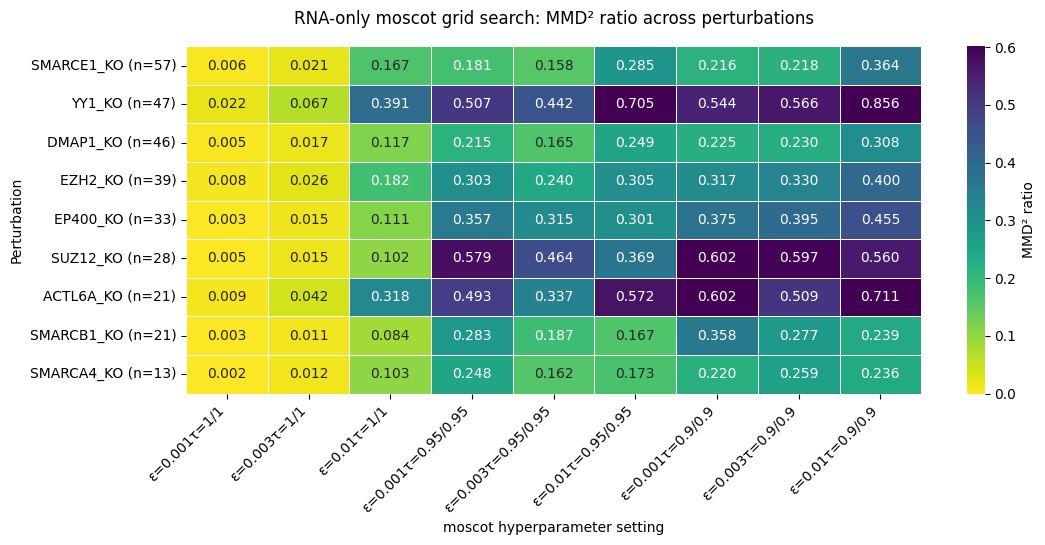

Saved: /content/drive/MyDrive/High_Dim_Bio_Stats/Project/moscot_RNA_only_end_to_end/figures/RNA_only_moscot_MMD2_ratio_heatmap_by_KO_and_config.png /content/drive/MyDrive/High_Dim_Bio_Stats/Project/moscot_RNA_only_end_to_end/figures/RNA_only_moscot_MMD2_ratio_heatmap_by_KO_and_config.pdf /content/drive/MyDrive/High_Dim_Bio_Stats/Project/moscot_RNA_only_end_to_end/figures/RNA_only_moscot_MMD2_ratio_heatmap_table.csv


In [12]:
# -----------------------------
# RNA-only grid-search heatmap using common RNA PCA evaluation
# -----------------------------
PLOT_DIR = Path(RUN_ROOT) / "figures"
PLOT_DIR.mkdir(parents=True, exist_ok=True)

df = summary_df.copy()
metric_col = 'mmd2_ratio_bary_to_pert_over_ctrl_to_pert'
required_cols = ['target_label', 'epsilon', 'tau_a', 'tau_b', 'n_perturbed_eval', metric_col]
missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f'Missing required columns: {missing}')

plot_df = df.copy()
plot_df['KO'] = plot_df['target_label'].astype(str).str.replace(' ', '_', regex=False)
plot_df['epsilon'] = plot_df['epsilon'].astype(float)
plot_df['tau_a'] = plot_df['tau_a'].astype(float)
plot_df['tau_b'] = plot_df['tau_b'].astype(float)
plot_df['n_perturbed_eval'] = plot_df['n_perturbed_eval'].astype(int)
plot_df[metric_col] = plot_df[metric_col].astype(float)

def fmt_float(x):
    return f'{float(x):g}'

plot_df['config_label'] = (
    'ε=' + plot_df['epsilon'].map(fmt_float) +
    'τ=' + plot_df['tau_a'].map(fmt_float) + '/' + plot_df['tau_b'].map(fmt_float)
)

plot_df = (
    plot_df
    .groupby(['KO', 'target_label', 'n_perturbed_eval', 'epsilon', 'tau_a', 'tau_b', 'config_label'], as_index=False)
    .agg({metric_col: 'mean'})
)

ko_order_df = (
    plot_df[['KO', 'n_perturbed_eval']]
    .drop_duplicates()
    .sort_values('n_perturbed_eval', ascending=False)
)
ko_order = ko_order_df['KO'].tolist()

config_order_df = (
    plot_df[['config_label', 'epsilon', 'tau_a', 'tau_b']]
    .drop_duplicates()
    .sort_values(['tau_a', 'tau_b', 'epsilon'], ascending=[False, False, True])
)
config_order = config_order_df['config_label'].tolist()

heatmap_df = plot_df.pivot(index='KO', columns='config_label', values=metric_col)
heatmap_df = heatmap_df.loc[ko_order, config_order]

ko_to_n = dict(zip(ko_order_df['KO'], ko_order_df['n_perturbed_eval']))
heatmap_df.index = [f'{ko} (n={ko_to_n[ko]})' for ko in heatmap_df.index]

display(heatmap_df)

VMIN = 0.0
VMAX = min(1.0, np.nanpercentile(heatmap_df.values, 95))
fig_w = max(8, 1.25 * heatmap_df.shape[1])
fig_h = max(4.5, 0.45 * heatmap_df.shape[0] + 1.5)

plt.figure(figsize=(fig_w, fig_h))
ax = sns.heatmap(
    heatmap_df,
    annot=True,
    fmt='.3f',
    linewidths=0.5,
    linecolor='white',
    cmap='viridis_r',
    vmin=VMIN,
    vmax=VMAX,
    cbar_kws={'label': 'MMD² ratio'}
)
ax.set_xlabel('moscot hyperparameter setting')
ax.set_ylabel('Perturbation')
ax.set_title('RNA-only moscot grid search: MMD² ratio across perturbations', pad=16)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()

png_path = PLOT_DIR / 'RNA_only_moscot_MMD2_ratio_heatmap_by_KO_and_config.png'
pdf_path = PLOT_DIR / 'RNA_only_moscot_MMD2_ratio_heatmap_by_KO_and_config.pdf'
table_path = PLOT_DIR / 'RNA_only_moscot_MMD2_ratio_heatmap_table.csv'
plt.savefig(png_path, dpi=300, bbox_inches='tight')
plt.savefig(pdf_path, bbox_inches='tight')
heatmap_df.to_csv(table_path)
plt.show()
print('Saved:', png_path, pdf_path, table_path)


## Copy global-best outputs


In [13]:
import shutil

GLOBAL_BEST_DIR = Path(HANDOFF_DIR) / "GLOBAL_BEST_RNA_only_all_KO"
GLOBAL_BEST_DIR.mkdir(parents=True, exist_ok=True)

global_manifest_rows = []

for _, row in global_best_rows.iterrows():
    matching = manifest_df[
        (manifest_df["target_label"].astype(str) == str(row["target_label"])) &
        (manifest_df["run_name"].astype(str) == str(row["run_name"]))
    ]
    if len(matching) != 1:
        print("Could not uniquely find manifest row for", row["target_label"], row["run_name"])
        continue

    info = matching.iloc[0].to_dict()
    slug = info["slug"]
    ko_dir = GLOBAL_BEST_DIR / slug
    ko_dir.mkdir(parents=True, exist_ok=True)

    copied = {}
    for key, suffix in [
        ("bary_path", "barycentric_source_to_target.h5ad"),
        ("transport_path", "transport_plan.npz"),
        ("input_path", "moscot_input.h5ad"),
        ("metrics_path", "metrics.csv"),
    ]:
        src = Path(info[key])
        dst = ko_dir / f"{slug}__GLOBAL_BEST__{suffix}"
        shutil.copy2(src, dst)
        copied[key] = str(dst)

    global_manifest_rows.append({
        "target_label": row["target_label"],
        "slug": slug,
        "global_best_run_name": row["run_name"],
        "epsilon": row["epsilon"],
        "tau_a": row["tau_a"],
        "tau_b": row["tau_b"],
        "mmd2_ratio_bary_to_pert_over_ctrl_to_pert": row["mmd2_ratio_bary_to_pert_over_ctrl_to_pert"],
        "clf_sep_auc_bary_vs_perturbed": row["clf_sep_auc_bary_vs_perturbed"],
        "clf_auc_dist_from_0p5_bary_vs_perturbed": row["clf_auc_dist_from_0p5_bary_vs_perturbed"],
        "effective_targets_per_source_median": row["effective_targets_per_source_median"],
        **copied,
    })

global_best_manifest_df = pd.DataFrame(global_manifest_rows)
global_best_manifest_path = GLOBAL_BEST_DIR / "GLOBAL_BEST_manifest.csv"
global_best_manifest_df.to_csv(global_best_manifest_path, index=False)

print("Global-best handoff folder:", GLOBAL_BEST_DIR)
print("Global-best manifest:", global_best_manifest_path)
display(global_best_manifest_df)


Global-best handoff folder: /content/drive/MyDrive/High_Dim_Bio_Stats/Project/moscot_RNA_only_end_to_end/handoff/GLOBAL_BEST_RNA_only_all_KO
Global-best manifest: /content/drive/MyDrive/High_Dim_Bio_Stats/Project/moscot_RNA_only_end_to_end/handoff/GLOBAL_BEST_RNA_only_all_KO/GLOBAL_BEST_manifest.csv


,target_label,slug,global_best_run_name,epsilon,tau_a,tau_b,mmd2_ratio_bary_to_pert_over_ctrl_to_pert,clf_sep_auc_bary_vs_perturbed,clf_auc_dist_from_0p5_bary_vs_perturbed,effective_targets_per_source_median,bary_path,transport_path,input_path,metrics_path
0,ACTL6A KO,ACTL6A_KO,rna_only_pca__eps0p001__taua1__taub1,0.001,1.0,1.0,0.009058,0.903382,0.403382,1.000854,/content/drive/MyDrive/High_Dim_Bio_Stats/Proj...,/content/drive/MyDrive/High_Dim_Bio_Stats/Proj...,/content/drive/MyDrive/High_Dim_Bio_Stats/Proj...,/content/drive/MyDrive/High_Dim_Bio_Stats/Proj...
1,DMAP1 KO,DMAP1_KO,rna_only_pca__eps0p001__taua1__taub1,0.001,1.0,1.0,0.004870,0.910455,0.410455,1.000188,/content/drive/MyDrive/High_Dim_Bio_Stats/Proj...,/content/drive/MyDrive/High_Dim_Bio_Stats/Proj...,/content/drive/MyDrive/High_Dim_Bio_Stats/Proj...,/content/drive/MyDrive/High_Dim_Bio_Stats/Proj...
2,EP400 KO,EP400_KO,rna_only_pca__eps0p001__taua1__taub1,0.001,1.0,1.0,0.003365,0.888406,0.388406,1.000003,/content/drive/MyDrive/High_Dim_Bio_Stats/Proj...,/content/drive/MyDrive/High_Dim_Bio_Stats/Proj...,/content/drive/MyDrive/High_Dim_Bio_Stats/Proj...,/content/drive/MyDrive/High_Dim_Bio_Stats/Proj...
3,EZH2 KO,EZH2_KO,rna_only_pca__eps0p001__taua1__taub1,0.001,1.0,1.0,0.008112,0.866546,0.366546,1.000044,/content/drive/MyDrive/High_Dim_Bio_Stats/Proj...,/content/drive/MyDrive/High_Dim_Bio_Stats/Proj...,/content/drive/MyDrive/High_Dim_Bio_Stats/Proj...,/content/drive/MyDrive/High_Dim_Bio_Stats/Proj...
4,SMARCA4 KO,SMARCA4_KO,rna_only_pca__eps0p001__taua1__taub1,0.001,1.0,1.0,0.002246,0.860507,0.360507,1.000000,/content/drive/MyDrive/High_Dim_Bio_Stats/Proj...,/content/drive/MyDrive/High_Dim_Bio_Stats/Proj...,/content/drive/MyDrive/High_Dim_Bio_Stats/Proj...,/content/drive/MyDrive/High_Dim_Bio_Stats/Proj...
5,SMARCB1 KO,SMARCB1_KO,rna_only_pca__eps0p001__taua1__taub1,0.001,1.0,1.0,0.002982,0.899758,0.399758,1.000000,/content/drive/MyDrive/High_Dim_Bio_Stats/Proj...,/content/drive/MyDrive/High_Dim_Bio_Stats/Proj...,/content/drive/MyDrive/High_Dim_Bio_Stats/Proj...,/content/drive/MyDrive/High_Dim_Bio_Stats/Proj...
6,SMARCE1 KO,SMARCE1_KO,rna_only_pca__eps0p001__taua1__taub1,0.001,1.0,1.0,0.005948,0.912191,0.412191,1.002537,/content/drive/MyDrive/High_Dim_Bio_Stats/Proj...,/content/drive/MyDrive/High_Dim_Bio_Stats/Proj...,/content/drive/MyDrive/High_Dim_Bio_Stats/Proj...,/content/drive/MyDrive/High_Dim_Bio_Stats/Proj...
7,SUZ12 KO,SUZ12_KO,rna_only_pca__eps0p001__taua1__taub1,0.001,1.0,1.0,0.004655,0.873214,0.373214,1.000000,/content/drive/MyDrive/High_Dim_Bio_Stats/Proj...,/content/drive/MyDrive/High_Dim_Bio_Stats/Proj...,/content/drive/MyDrive/High_Dim_Bio_Stats/Proj...,/content/drive/MyDrive/High_Dim_Bio_Stats/Proj...
8,YY1 KO,YY1_KO,rna_only_pca__eps0p001__taua1__taub1,0.001,1.0,1.0,0.022293,0.868012,0.368012,1.000019,/content/drive/MyDrive/High_Dim_Bio_Stats/Proj...,/content/drive/MyDrive/High_Dim_Bio_Stats/Proj...,/content/drive/MyDrive/High_Dim_Bio_Stats/Proj...,/content/drive/MyDrive/High_Dim_Bio_Stats/Proj...


## Additional diagnostic plots


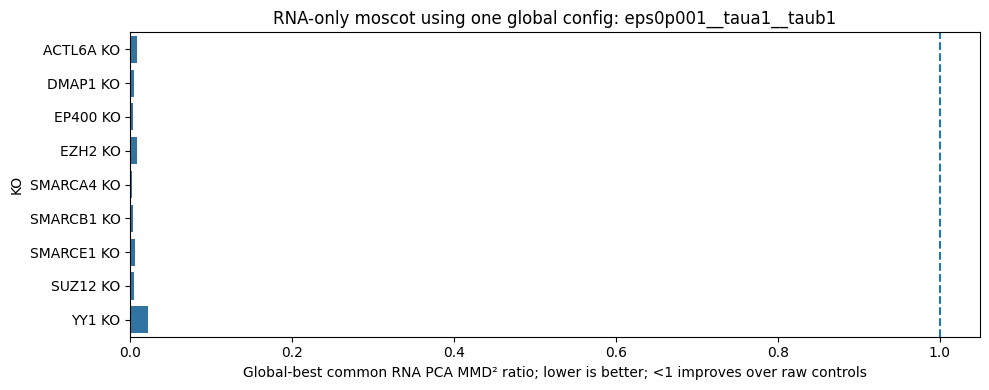

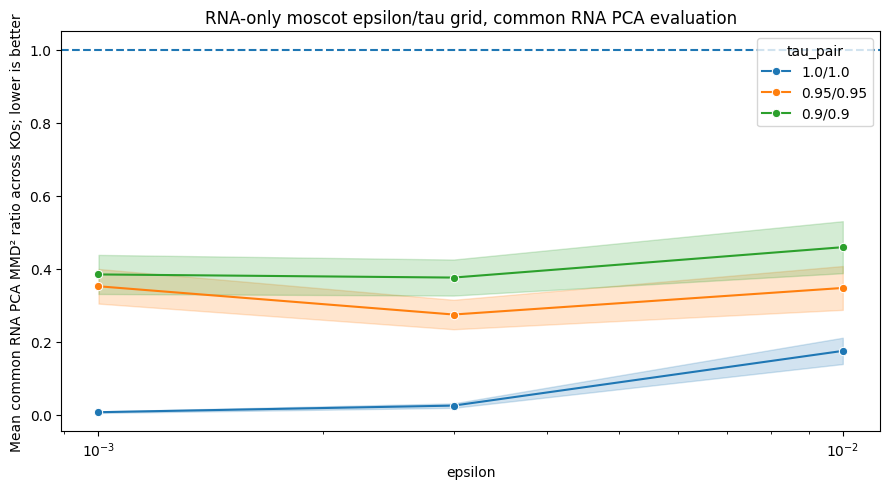

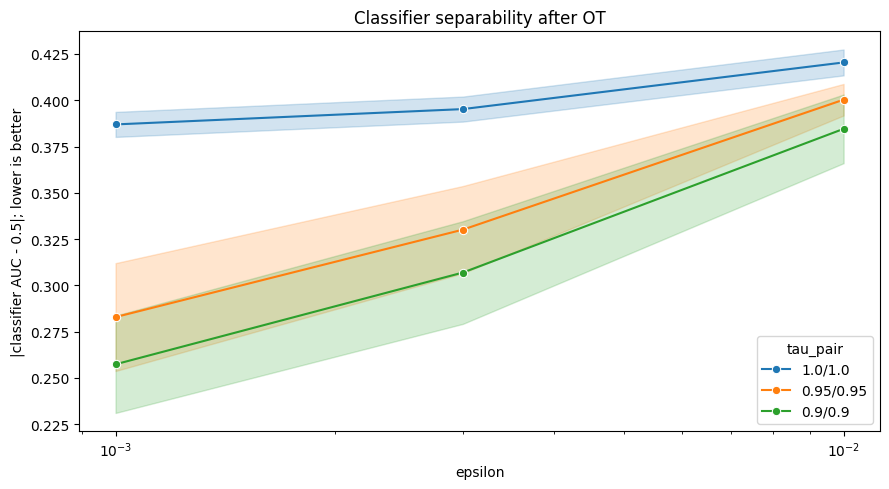

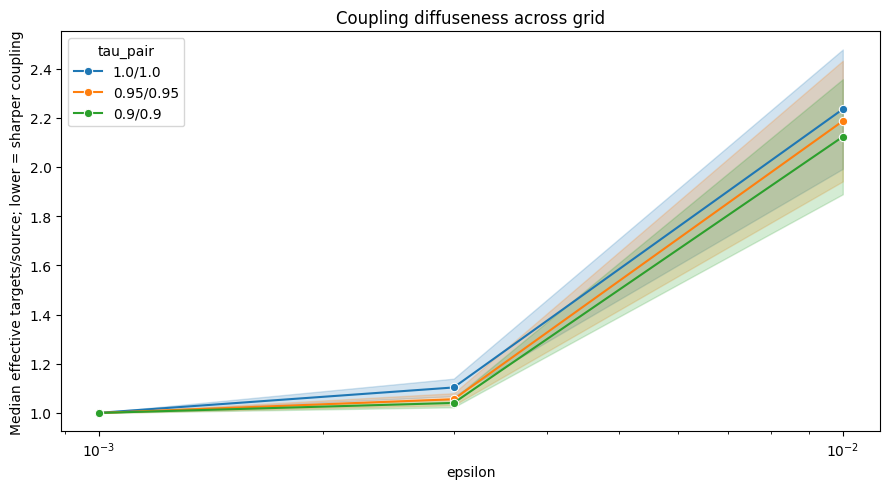

Saved plots to: /content/drive/MyDrive/High_Dim_Bio_Stats/Project/moscot_RNA_only_end_to_end/plots


In [14]:
plot_dir = Path(RUN_ROOT) / "plots"
plot_dir.mkdir(exist_ok=True, parents=True)

plot_df = summary_df.copy()
plot_df["tau_pair"] = plot_df["tau_a"].astype(str) + "/" + plot_df["tau_b"].astype(str)

global_best_plot_df = global_best_rows.copy()

plt.figure(figsize=(10, max(4, 0.35 * global_best_plot_df["target_label"].nunique())))
sns.barplot(
    data=global_best_plot_df,
    y="target_label",
    x="mmd2_ratio_bary_to_pert_over_ctrl_to_pert",
)
plt.axvline(1.0, linestyle="--")
plt.xlabel("Global-best common RNA PCA MMD² ratio; lower is better; <1 improves over raw controls")
plt.ylabel("KO")
plt.title(f"RNA-only moscot using one global config: {best_global_name}")
plt.tight_layout()
plt.savefig(plot_dir / "global_best_mmd_ratio_by_KO.png", dpi=150, bbox_inches="tight")
plt.show()

plt.figure(figsize=(9, 5))
sns.lineplot(
    data=plot_df,
    x="epsilon",
    y="mmd2_ratio_bary_to_pert_over_ctrl_to_pert",
    hue="tau_pair",
    marker="o",
    errorbar="se",
)
plt.xscale("log")
plt.axhline(1.0, linestyle="--")
plt.xlabel("epsilon")
plt.ylabel("Mean common RNA PCA MMD² ratio across KOs; lower is better")
plt.title("RNA-only moscot epsilon/tau grid, common RNA PCA evaluation")
plt.tight_layout()
plt.savefig(plot_dir / "epsilon_tau_grid_mmd_ratio.png", dpi=150, bbox_inches="tight")
plt.show()

plt.figure(figsize=(9, 5))
sns.lineplot(
    data=plot_df,
    x="epsilon",
    y="clf_auc_dist_from_0p5_bary_vs_perturbed",
    hue="tau_pair",
    marker="o",
    errorbar="se",
)
plt.xscale("log")
plt.xlabel("epsilon")
plt.ylabel("|classifier AUC - 0.5|; lower is better")
plt.title("Classifier separability after OT")
plt.tight_layout()
plt.savefig(plot_dir / "epsilon_tau_grid_classifier_separability.png", dpi=150, bbox_inches="tight")
plt.show()

plt.figure(figsize=(9, 5))
sns.lineplot(
    data=plot_df,
    x="epsilon",
    y="effective_targets_per_source_median",
    hue="tau_pair",
    marker="o",
    errorbar="se",
)
plt.xscale("log")
plt.xlabel("epsilon")
plt.ylabel("Median effective targets/source; lower = sharper coupling")
plt.title("Coupling diffuseness across grid")
plt.tight_layout()
plt.savefig(plot_dir / "epsilon_tau_grid_coupling_diffuseness.png", dpi=150, bbox_inches="tight")
plt.show()

print("Saved plots to:", plot_dir)


## Create compact final handoff folder


In [15]:
# ============================================================
# FINAL CLEAN MODEL HANDOFF FOLDER
# ============================================================
# This cell creates ONE clean folder containing only the files your teammate needs:
#   - source/control inputs used by OT
#   - barycentric mapped controls (main target)
#   - real perturbed/target cells used by OT
#   - obs metadata for source, mapped, and target cells
#   - a compact manifest + README
#
# It reads from the existing GLOBAL_BEST_RNA_only_all_KO folder. You do NOT need
# source/target .npy files already saved, because they are inside each
# *_moscot_input.h5ad file.

import os
import json
import shutil
from pathlib import Path

import numpy as np
import pandas as pd
import scanpy as sc

# Existing production folder from the notebook.
# Should contain one subfolder per KO with:
#   *_barycentric_source_to_target.h5ad
#   *_moscot_input.h5ad
#   *_transport_plan.npz
#   *_metrics.csv
GLOBAL_BEST_DIR = Path(HANDOFF_DIR) / "GLOBAL_BEST_RNA_only_all_KO"

# New folder to send to your teammate.
FINAL_MODEL_HANDOFF_DIR = Path(HANDOFF_DIR) / "FINAL_MODEL_HANDOFF_minimal"
FINAL_MODEL_HANDOFF_DIR.mkdir(parents=True, exist_ok=True)

print("Reading from:", GLOBAL_BEST_DIR)
print("Writing clean handoff to:", FINAL_MODEL_HANDOFF_DIR)
assert GLOBAL_BEST_DIR.exists(), f"Missing global-best folder: {GLOBAL_BEST_DIR}"


def _find_one(folder: Path, contains: str):
    matches = sorted([p for p in folder.iterdir() if p.is_file() and contains in p.name])
    if len(matches) == 0:
        raise FileNotFoundError(f"No file containing '{contains}' found in {folder}")
    if len(matches) > 1:
        print(f"Warning: multiple files containing '{contains}' in {folder}; using {matches[0].name}")
    return matches[0]


def _dense(X):
    try:
        import scipy.sparse as sp
        if sp.issparse(X):
            return X.toarray()
    except Exception:
        pass
    return np.asarray(X)


manifest_rows = []
ko_dirs = sorted([p for p in GLOBAL_BEST_DIR.iterdir() if p.is_dir()])
print(f"Found {len(ko_dirs)} KO folders")

for ko_dir in ko_dirs:
    slug = ko_dir.name
    print(f"\nProcessing {slug}...")

    bary_h5ad = _find_one(ko_dir, "barycentric_source_to_target.h5ad")
    input_h5ad = _find_one(ko_dir, "moscot_input.h5ad")
    metrics_csv = _find_one(ko_dir, "metrics.csv")
    transport_npz = _find_one(ko_dir, "transport_plan.npz")

    # Load h5ads.
    # moscot_input contains both source/control and target/perturbed cells.
    adata_in = sc.read_h5ad(input_h5ad)
    adata_bary = sc.read_h5ad(bary_h5ad)

    # Identify source/control and target/perturbed rows.
    # The clean notebook sets ko.obs['condition'] to ['control', 'perturbed'].
    if "condition" not in adata_in.obs.columns:
        raise ValueError(f"{input_h5ad} does not contain obs['condition']")

    source_mask = adata_in.obs["condition"].astype(str).eq("control").values
    target_mask = adata_in.obs["condition"].astype(str).eq("perturbed").values

    if source_mask.sum() == 0 or target_mask.sum() == 0:
        raise ValueError(
            f"Could not find both control and perturbed rows in {input_h5ad}. "
            f"Counts: control={source_mask.sum()}, perturbed={target_mask.sum()}"
        )

    X_source = _dense(adata_in.X[source_mask]).astype(np.float32)
    X_target = _dense(adata_in.X[target_mask]).astype(np.float32)
    X_mapped = _dense(adata_bary.X).astype(np.float32)

    source_obs = adata_in.obs.loc[source_mask].copy()
    target_obs = adata_in.obs.loc[target_mask].copy()
    mapped_obs = adata_bary.obs.copy()

    # Basic consistency checks.
    assert X_source.shape[0] == X_mapped.shape[0], (
        f"For {slug}, source rows ({X_source.shape[0]}) != mapped rows ({X_mapped.shape[0]})"
    )
    assert X_source.shape[1] == X_mapped.shape[1] == X_target.shape[1], (
        f"For {slug}, feature dimensions disagree: "
        f"source={X_source.shape}, mapped={X_mapped.shape}, target={X_target.shape}"
    )

    # Per-KO clean folder.
    out_dir = FINAL_MODEL_HANDOFF_DIR / slug
    out_dir.mkdir(parents=True, exist_ok=True)

    # Save arrays. These are the main files for ML.
    np.save(out_dir / "X_source_control_RNA_PCA.npy", X_source)
    np.save(out_dir / "X_mapped_barycentric_RNA_PCA.npy", X_mapped)
    np.save(out_dir / "X_target_perturbed_RNA_PCA.npy", X_target)

    # Save metadata. Row order matches the corresponding .npy files.
    source_obs.to_csv(out_dir / "obs_source_control.csv")
    mapped_obs.to_csv(out_dir / "obs_mapped_barycentric.csv")
    target_obs.to_csv(out_dir / "obs_target_perturbed.csv")

    # Copy compact run info only. Transport plan is optional, but useful if she wants cell-level weights.
    shutil.copy2(metrics_csv, out_dir / "metrics.csv")
    shutil.copy2(transport_npz, out_dir / "transport_plan_optional.npz")

    manifest_rows.append({
        "KO": slug,
        "source_n_cells": int(X_source.shape[0]),
        "mapped_n_cells": int(X_mapped.shape[0]),
        "target_n_cells": int(X_target.shape[0]),
        "n_features_RNA_PCs": int(X_source.shape[1]),
        "X_source_control_RNA_PCA": str(out_dir / "X_source_control_RNA_PCA.npy"),
        "X_mapped_barycentric_RNA_PCA": str(out_dir / "X_mapped_barycentric_RNA_PCA.npy"),
        "X_target_perturbed_RNA_PCA": str(out_dir / "X_target_perturbed_RNA_PCA.npy"),
        "obs_source_control": str(out_dir / "obs_source_control.csv"),
        "obs_mapped_barycentric": str(out_dir / "obs_mapped_barycentric.csv"),
        "obs_target_perturbed": str(out_dir / "obs_target_perturbed.csv"),
        "metrics": str(out_dir / "metrics.csv"),
        "transport_plan_optional": str(out_dir / "transport_plan_optional.npz"),
    })

    print(f"  X_source: {X_source.shape}")
    print(f"  X_mapped: {X_mapped.shape}")
    print(f"  X_target: {X_target.shape}")

manifest_final = pd.DataFrame(manifest_rows)
manifest_path = FINAL_MODEL_HANDOFF_DIR / "manifest_FINAL_MODEL_HANDOFF.csv"
manifest_final.to_csv(manifest_path, index=False)

readme = f"""
# Final minimal model handoff

This folder contains the clean RNA-only moscot outputs for downstream modeling.

## Most important file per KO

- `X_mapped_barycentric_RNA_PCA.npy`
  - This is the barycentric OT projection: each control/source cell mapped toward the KO/perturbed distribution.
  - Row order matches `X_source_control_RNA_PCA.npy`.

## Files per KO

- `X_source_control_RNA_PCA.npy`
  - Control/source cells in the processed RNA PCA feature space used by moscot.

- `X_mapped_barycentric_RNA_PCA.npy`
  - Main downstream target. Same number/order of rows as the source/control file.

- `X_target_perturbed_RNA_PCA.npy`
  - Real perturbed cells in the same processed RNA PCA feature space. Useful for evaluation/comparison.

- `obs_source_control.csv`, `obs_mapped_barycentric.csv`, `obs_target_perturbed.csv`
  - Metadata. Row order matches the corresponding `.npy` file.

- `transport_plan_optional.npz`
  - Optional low-level OT transport matrix. Not needed for most ML workflows.

- `metrics.csv`
  - Alignment metrics for this KO under the selected global moscot config.

## Important caveat

These arrays are in the shared RNA PCA space used by moscot, not raw gene expression.
The mapping is symmetric finite-sample OT/barycentric projection, not a learned neural perturbation model.

## Selected global moscot config

- epsilon: {best_global_config.get('epsilon', 'NA') if 'best_global_config' in globals() else 'NA'}
- tau_a: {best_global_config.get('tau_a', 'NA') if 'best_global_config' in globals() else 'NA'}
- tau_b: {best_global_config.get('tau_b', 'NA') if 'best_global_config' in globals() else 'NA'}
"""
readme_path = FINAL_MODEL_HANDOFF_DIR / "README_FINAL_MODEL_HANDOFF.md"
readme_path.write_text(readme)

print("\nDONE")
print("Final handoff folder:", FINAL_MODEL_HANDOFF_DIR)
print("Manifest:", manifest_path)
display(manifest_final)


Reading from: /content/drive/MyDrive/High_Dim_Bio_Stats/Project/moscot_RNA_only_end_to_end/handoff/GLOBAL_BEST_RNA_only_all_KO
Writing clean handoff to: /content/drive/MyDrive/High_Dim_Bio_Stats/Project/moscot_RNA_only_end_to_end/handoff/FINAL_MODEL_HANDOFF_minimal
Found 9 KO folders

Processing ACTL6A_KO...
  X_source: (229, 50)
  X_mapped: (229, 50)
  X_target: (21, 50)

Processing DMAP1_KO...
  X_source: (229, 50)
  X_mapped: (229, 50)
  X_target: (46, 50)

Processing EP400_KO...
  X_source: (229, 50)
  X_mapped: (229, 50)
  X_target: (33, 50)

Processing EZH2_KO...
  X_source: (229, 50)
  X_mapped: (229, 50)
  X_target: (39, 50)

Processing SMARCA4_KO...
  X_source: (229, 50)
  X_mapped: (229, 50)
  X_target: (13, 50)

Processing SMARCB1_KO...
  X_source: (229, 50)
  X_mapped: (229, 50)
  X_target: (21, 50)

Processing SMARCE1_KO...
  X_source: (229, 50)
  X_mapped: (229, 50)
  X_target: (57, 50)

Processing SUZ12_KO...
  X_source: (229, 50)
  X_mapped: (229, 50)
  X_target: (28, 5

,KO,source_n_cells,mapped_n_cells,target_n_cells,n_features_RNA_PCs,X_source_control_RNA_PCA,X_mapped_barycentric_RNA_PCA,X_target_perturbed_RNA_PCA,obs_source_control,obs_mapped_barycentric,obs_target_perturbed,metrics,transport_plan_optional
0,ACTL6A_KO,229,229,21,50,/content/drive/MyDrive/High_Dim_Bio_Stats/Proj...,/content/drive/MyDrive/High_Dim_Bio_Stats/Proj...,/content/drive/MyDrive/High_Dim_Bio_Stats/Proj...,/content/drive/MyDrive/High_Dim_Bio_Stats/Proj...,/content/drive/MyDrive/High_Dim_Bio_Stats/Proj...,/content/drive/MyDrive/High_Dim_Bio_Stats/Proj...,/content/drive/MyDrive/High_Dim_Bio_Stats/Proj...,/content/drive/MyDrive/High_Dim_Bio_Stats/Proj...
1,DMAP1_KO,229,229,46,50,/content/drive/MyDrive/High_Dim_Bio_Stats/Proj...,/content/drive/MyDrive/High_Dim_Bio_Stats/Proj...,/content/drive/MyDrive/High_Dim_Bio_Stats/Proj...,/content/drive/MyDrive/High_Dim_Bio_Stats/Proj...,/content/drive/MyDrive/High_Dim_Bio_Stats/Proj...,/content/drive/MyDrive/High_Dim_Bio_Stats/Proj...,/content/drive/MyDrive/High_Dim_Bio_Stats/Proj...,/content/drive/MyDrive/High_Dim_Bio_Stats/Proj...
2,EP400_KO,229,229,33,50,/content/drive/MyDrive/High_Dim_Bio_Stats/Proj...,/content/drive/MyDrive/High_Dim_Bio_Stats/Proj...,/content/drive/MyDrive/High_Dim_Bio_Stats/Proj...,/content/drive/MyDrive/High_Dim_Bio_Stats/Proj...,/content/drive/MyDrive/High_Dim_Bio_Stats/Proj...,/content/drive/MyDrive/High_Dim_Bio_Stats/Proj...,/content/drive/MyDrive/High_Dim_Bio_Stats/Proj...,/content/drive/MyDrive/High_Dim_Bio_Stats/Proj...
3,EZH2_KO,229,229,39,50,/content/drive/MyDrive/High_Dim_Bio_Stats/Proj...,/content/drive/MyDrive/High_Dim_Bio_Stats/Proj...,/content/drive/MyDrive/High_Dim_Bio_Stats/Proj...,/content/drive/MyDrive/High_Dim_Bio_Stats/Proj...,/content/drive/MyDrive/High_Dim_Bio_Stats/Proj...,/content/drive/MyDrive/High_Dim_Bio_Stats/Proj...,/content/drive/MyDrive/High_Dim_Bio_Stats/Proj...,/content/drive/MyDrive/High_Dim_Bio_Stats/Proj...
4,SMARCA4_KO,229,229,13,50,/content/drive/MyDrive/High_Dim_Bio_Stats/Proj...,/content/drive/MyDrive/High_Dim_Bio_Stats/Proj...,/content/drive/MyDrive/High_Dim_Bio_Stats/Proj...,/content/drive/MyDrive/High_Dim_Bio_Stats/Proj...,/content/drive/MyDrive/High_Dim_Bio_Stats/Proj...,/content/drive/MyDrive/High_Dim_Bio_Stats/Proj...,/content/drive/MyDrive/High_Dim_Bio_Stats/Proj...,/content/drive/MyDrive/High_Dim_Bio_Stats/Proj...
5,SMARCB1_KO,229,229,21,50,/content/drive/MyDrive/High_Dim_Bio_Stats/Proj...,/content/drive/MyDrive/High_Dim_Bio_Stats/Proj...,/content/drive/MyDrive/High_Dim_Bio_Stats/Proj...,/content/drive/MyDrive/High_Dim_Bio_Stats/Proj...,/content/drive/MyDrive/High_Dim_Bio_Stats/Proj...,/content/drive/MyDrive/High_Dim_Bio_Stats/Proj...,/content/drive/MyDrive/High_Dim_Bio_Stats/Proj...,/content/drive/MyDrive/High_Dim_Bio_Stats/Proj...
6,SMARCE1_KO,229,229,57,50,/content/drive/MyDrive/High_Dim_Bio_Stats/Proj...,/content/drive/MyDrive/High_Dim_Bio_Stats/Proj...,/content/drive/MyDrive/High_Dim_Bio_Stats/Proj...,/content/drive/MyDrive/High_Dim_Bio_Stats/Proj...,/content/drive/MyDrive/High_Dim_Bio_Stats/Proj...,/content/drive/MyDrive/High_Dim_Bio_Stats/Proj...,/content/drive/MyDrive/High_Dim_Bio_Stats/Proj...,/content/drive/MyDrive/High_Dim_Bio_Stats/Proj...
7,SUZ12_KO,229,229,28,50,/content/drive/MyDrive/High_Dim_Bio_Stats/Proj...,/content/drive/MyDrive/High_Dim_Bio_Stats/Proj...,/content/drive/MyDrive/High_Dim_Bio_Stats/Proj...,/content/drive/MyDrive/High_Dim_Bio_Stats/Proj...,/content/drive/MyDrive/High_Dim_Bio_Stats/Proj...,/content/drive/MyDrive/High_Dim_Bio_Stats/Proj...,/content/drive/MyDrive/High_Dim_Bio_Stats/Proj...,/content/drive/MyDrive/High_Dim_Bio_Stats/Proj...
8,YY1_KO,229,229,47,50,/content/drive/MyDrive/High_Dim_Bio_Stats/Proj...,/content/drive/MyDrive/High_Dim_Bio_Stats/Proj...,/content/drive/MyDrive/High_Dim_Bio_Stats/Proj...,/content/drive/MyDrive/High_Dim_Bio_Stats/Proj...,/content/drive/MyDrive/High_Dim_Bio_Stats/Proj...,/content/drive/MyDrive/High_Dim_Bio_Stats/Proj...,/content/drive/MyDrive/High

## Write README


In [16]:
# -----------------------------
# Write a compact handoff README
# -----------------------------
readme_text = f"""
# RNA-only moscot handoff

This folder contains the RNA-only moscot outputs for control cells aligned to each KO population.

## Main folders

- `handoff/GLOBAL_BEST_RNA_only_all_KO/`: one selected run per KO using the global-best epsilon/tau setting.
- `handoff/FINAL_MODEL_HANDOFF_minimal/`: compact NumPy/CSV export for downstream modeling.
- `figures/`: heatmap figure and heatmap table using common RNA PCA evaluation.

## Main files

- `moscot_RNA_only_all_KO_summary.csv`: one row per KO x epsilon x tau setting, recomputed using common RNA PCA plan-barycenter evaluation with a shared RBF-MMD bandwidth.
- `handoff/manifest.csv`: paths for every per-KO run.
- `handoff/GLOBAL_BEST_RNA_only_all_KO/GLOBAL_BEST_manifest.csv`: paths for selected global-best outputs.
- `handoff/FINAL_MODEL_HANDOFF_minimal/final_model_handoff_manifest.csv`: compact manifest for teammate handoff.
"""

readme_path = Path(RUN_ROOT) / "README.md"
readme_path.write_text(readme_text)
print("Saved README:", readme_path)


Saved README: /content/drive/MyDrive/High_Dim_Bio_Stats/Project/moscot_RNA_only_end_to_end/README.md
